<a href="https://colab.research.google.com/github/sudipta-on/Qiskit_v2_HandsOn/blob/main/QuantumErrorCorrection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="font-family:'Times New Roman', Times, serif; padding:18px; border-radius:12px;
background: linear-gradient(135deg,#fff5f5,#ffecec); border:2px solid #ffcccc;">

<h1 style="font-size:38px; text-align:center; font-weight:bold; color:#b30000; margin-bottom:6px;">
🛡️ Quantum Error Correction & Noise Channels
</h1>

<p style="font-size:20px; text-align:center; color:#333; margin-top:0;">
Understanding <b>Decoherence</b>, <b>Quantum Noise</b>, and how <b>Error Correction Codes</b> protect quantum information
</p>

<hr style="border:1px solid #ffb3b3; margin:12px 0;">

<p style="font-size:19px; color:#8b0000; text-align:left;">
📘 <b>Course:</b> Quantum Mechanics and Quantum Computation (QMQC)
</p>

<p style="font-size:17px; color:#444; text-align:right;">
⚛️ Hands-on exploration of noise models, error channels, and QEC using <b>Qiskit SDK (v2.0+)</b>
</p>

</div>

<div style="font-family:'Times New Roman', serif; font-size:16px; line-height:1.7;">

<h2 style="color:#1a237e; font-weight:600; border-bottom:2px solid #c5cae9; padding-bottom:4px;">
Chapter 1 : Quantum Noise and Error Channels
</h2>

<p>
In practical quantum systems, qubits inevitably interact with their surrounding environment.
This interaction leads to <b>decoherence</b> and <b>operational errors</b>, which degrade quantum information.
To systematically describe these effects, we use the framework of <b>quantum channels</b>.
</p>

<p>
A quantum channel is mathematically represented as a completely positive, trace-preserving (CPTP) map:
</p>

$$ {\large \rho_s \rightarrow \mathcal{E}(\rho_s) = \sum_k E_k \rho_s E_k^\dagger}$$
<p>
where:
<ul>
<li>$E_k$ are <b>Kraus operators</b> describing system-environment interaction</li>
<li>$\sum_k E_k^\dagger E_k = I$ ensures probability conservation</li>
</ul>
</p>

<p>This formalism provides a unified way to model different types of quantum noise.</p>

<hr style="border:1px solid #e0e0e0; margin:12px 0;">

<h4 style="color:green; font-weight:600;">
1.1 Bit-Flip Error Channel
</h4>

<p>The bit-flip error is the quantum analogue of a classical bit error, where the computational basis states are exchanged: $\quad |0\rangle \leftrightarrow |1\rangle$</p>

<p>This error is represented using the Pauli-X operator and occurs with probability $p$. $${\large \mathcal{E}(\rho_s) = (1 - p)\rho_s + p X \rho_s X}$$</p>

<p><b>Kraus representation:</b> $E_0 = \sqrt{1 - p}\, I, \quad E_1 = \sqrt{p}\, X$</p>

<p>
The bit-flip channel captures stochastic transitions between basis states and forms the simplest model of quantum noise.
</p>

<hr style="border:1px solid #e0e0e0; margin:12px 0;">

<h4 style="color:green; font-weight:600;">
1.2 Phase-Flip Error Channel
</h4>

<p>
A phase-flip error changes the relative phase of a quantum state without altering measurement probabilities in the computational basis: $\quad |+\rangle \leftrightarrow |-\rangle$
</p>

$${\large \mathcal{E}(\rho_s) = (1 - p)\rho_s + p Z \rho_s Z}$$

<p><b>Kraus representation:</b> $E_0 = \sqrt{1 - p}\, I, \quad E_1 = \sqrt{p}\, Z$
</p>

<p>
This error primarily affects quantum interference and coherence.
</p>

<hr style="border:1px solid #e0e0e0; margin:12px 0;">

<h4 style="color:green; font-weight:600;">
1.3 Depolarizing Channel
</h4>

<p>
Depolarizing noise models random errors where all Pauli operations occur with equal probability.
</p>

$${\large \mathcal{E}(\rho_s) = (1 - p)\rho_s + \frac{p}{3}(X\rho_s X + Y\rho_s Y + Z\rho_s Z) = (1-p) \rho_s + p \frac{I}{2}}$$

<p>
This channel represents complete loss of quantum information with probability $p$.
</p>

<hr style="border:1px solid #e0e0e0; margin:12px 0;">

<h4 style="color:green; font-weight:600;">
1.4 Amplitude Damping Channel
</h4>

<p>
Amplitude damping models energy dissipation, such as spontaneous emission: $\quad |1\rangle \rightarrow |0\rangle$
</p>
<p><b>Kraus representation:</b></p>

$$E_0 =
\begin{pmatrix}
1 & 0 \\
0 & \sqrt{1 - \gamma}
\end{pmatrix}, \quad
E_1 =
\begin{pmatrix}
0 & \sqrt{\gamma} \\
0 & 0
\end{pmatrix}$$

<p>
This channel captures irreversible loss of excitation to the environment.
</p>

</div>

<a id="setup"></a>
<h2 style="color:blue; font-family:'Times New Roman', Times, serif; font-weight:bold">Installation and Imports
</h2>
Run the below code to install required packages

In [ ]:
!pip install qiskit qiskit_aer qiskit_algorithms qiskit_ibm_runtime pylatexenc -q

In [ ]:
from qiskit import QuantumCircuit, transpile, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, pauli_error, depolarizing_error
from qiskit.visualization import plot_histogram

import numpy as np

In [ ]:
# Helper Function (To create custom state from input bit-string)
def create_state(bitstring):
    n = len(bitstring)
    qc = QuantumCircuit(n, n)

    for i, bit in enumerate(bitstring):
        if bit == '1':
            qc.x(i)

    qc.barrier()
    qc.measure(range(n), range(n))
    return qc

# Helper Function (to run the circuit in noisy environment)
def run_circuit(qc, noise_model=None, shots=1024):
    sim = AerSimulator(noise_model=noise_model, shots=shots)
    result = sim.run(qc).result()
    return result.get_counts()

In [ ]:
# bit-flip noise model
def bit_flip_noise(p=0.1):
    error = pauli_error([('X', p), ('I', 1-p)])
    noise = NoiseModel()
    noise.add_all_qubit_quantum_error(error, ['x','id'])
    return noise

# phase-flip noise model
def phase_flip_noise(p=0.1):
    error = pauli_error([('Z', p), ('I', 1-p)])
    noise = NoiseModel()
    noise.add_all_qubit_quantum_error(error, ['h', 'x', 'z', 'id'])
    return noise

# depolarizing noise model
def depolarizing_noise(p=0.1):
    error = depolarizing_error(p, 1)
    noise = NoiseModel()
    noise.add_all_qubit_quantum_error(error, ['x', 'h', 'id'])
    return noise

Original (Ideal) Output:
{'10101': 1024}

After Bit-Flip Noise:
{'00001': 1, '10001': 51, '10100': 34, '10000': 3, '00101': 39, '10101': 896}

After Phase-Flip Noise:
{'10101': 1024}

After Depolarizing Noise:
{'00001': 1, '00101': 28, '10100': 30, '10001': 23, '10101': 942}


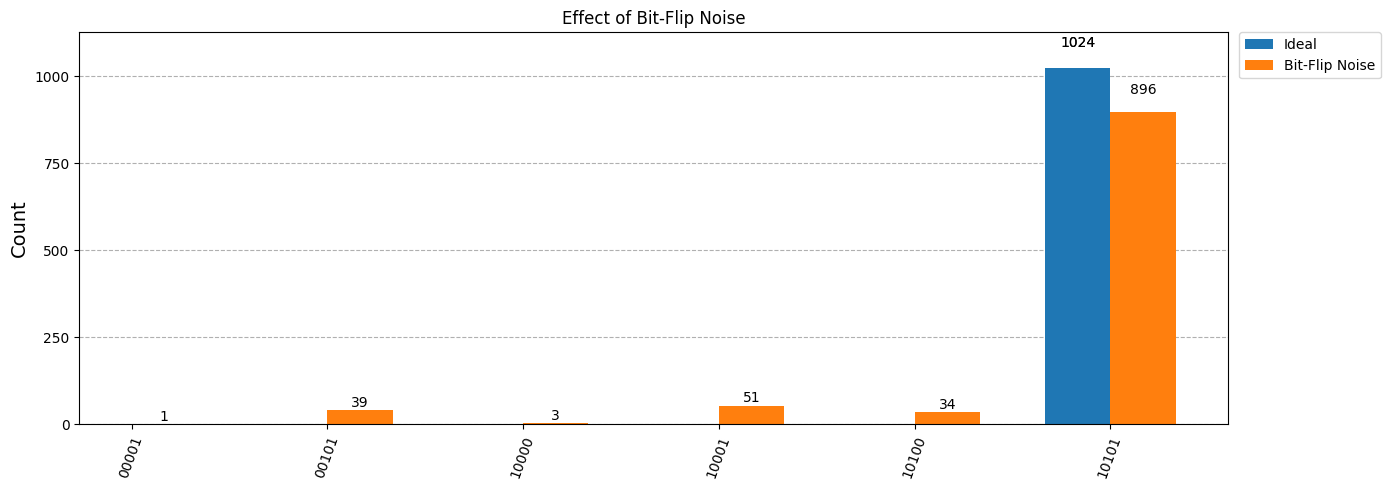

In [ ]:
bitstring = "10101"   # Classical information to encode
shots = 1024          # Number of measurement shots

qc = create_state(bitstring)

counts_clean = run_circuit(qc, shots=shots)

# Bit-flip noise (X errors)
bit_noise = bit_flip_noise(p=0.05)

# Phase-flip noise (Z errors)
phase_noise = phase_flip_noise(p=0.05)

# Depolarizing noise (random X, Y, Z errors)
dep_noise = depolarizing_noise(p=0.05)

bit_counts_noisy = run_circuit(qc, bit_noise, shots=shots)
phase_counts_noisy = run_circuit(qc, phase_noise, shots=shots)
dep_counts_noisy = run_circuit(qc, dep_noise, shots=shots)

print("Original (Ideal) Output:")
print(counts_clean)

print("\nAfter Bit-Flip Noise:")
print(bit_counts_noisy)

print("\nAfter Phase-Flip Noise:")
print(phase_counts_noisy)

print("\nAfter Depolarizing Noise:")
print(dep_counts_noisy)

# Bit-flip comparison
plot_histogram([counts_clean, bit_counts_noisy],figsize=(14,5), legend=['Ideal', 'Bit-Flip Noise'], title="Effect of Bit-Flip Noise")

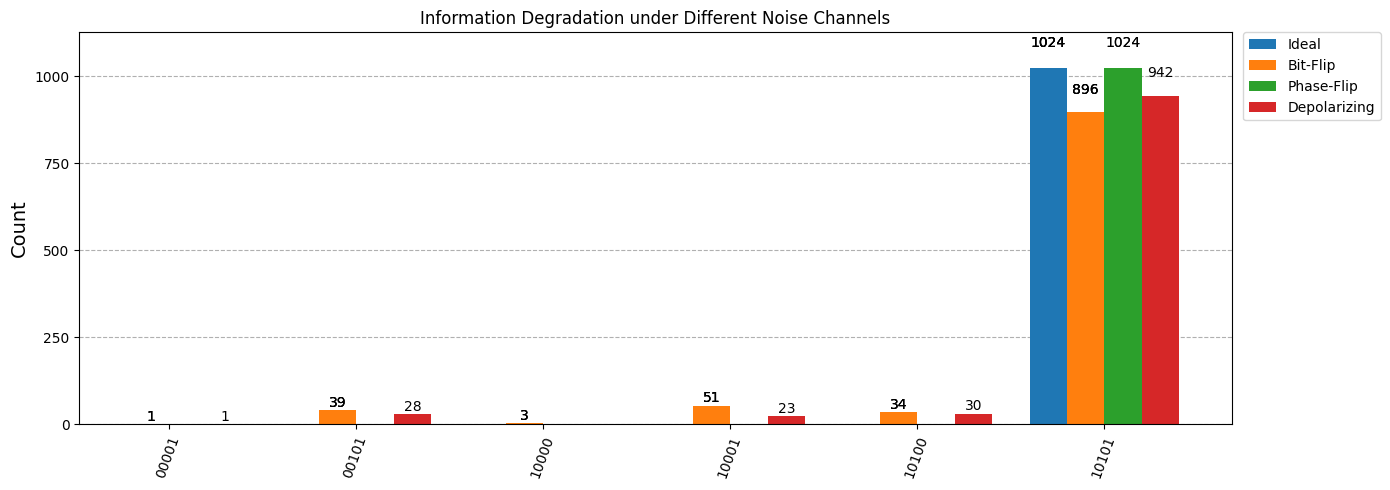

In [ ]:
plot_histogram(
    [counts_clean, bit_counts_noisy, phase_counts_noisy, dep_counts_noisy],
    legend=['Ideal', 'Bit-Flip', 'Phase-Flip', 'Depolarizing'],
    figsize=(14,5),
    title="Information Degradation under Different Noise Channels"
)

<div style="font-family:'Times New Roman', serif; font-size:16px; line-height:1.7;">

<h2 style="color:#1a237e; font-weight:600; border-bottom:2px solid #c5cae9; padding-bottom:4px;">
Chapter 2: Quantum Error Correction Codes
</h2>

<p>
Quantum error correction enables the reliable transmission of quantum information through noisy channels without directly measuring the quantum state.
The key idea is to encode a single logical qubit into a larger entangled system such that errors can be detected and corrected.
</p>

<hr style="border:1px solid #e0e0e0; margin:12px 0;">
<h3 style="color:green; font-weight:600;">
2.1 Bit-Flip Error Correction (3-Qubit Code)
</h3>

<p>
Consider a qubit transmitted through a noisy channel: $|\psi\rangle = \alpha|0\rangle + \beta|1\rangle$
</p>

<p>
To protect against bit-flip ($X$) errors, we encode it into three qubits: $|\psi_1\rangle = \alpha|000\rangle + \beta|111\rangle$
</p>

<p>
This encoding is implemented using two CNOT gates and two ancilla qubits initialized in $|0\rangle$.
</p>

<p>
During transmission, a single bit-flip error may occur on any qubit:
</p>

<ul>
<li>$\alpha|000\rangle + \beta|111\rangle$ (no error)</li>
<li>$\alpha|100\rangle + \beta|011\rangle$ (error on qubit 1)</li>
<li>$\alpha|010\rangle + \beta|101\rangle$ (error on qubit 2)</li>
<li>$\alpha|001\rangle + \beta|110\rangle$ (error on qubit 3)</li>
</ul>

<div style="text-align:center; margin:15px 0;">
<img src="https://raw.githubusercontent.com/qiskit-community/qiskit-community-tutorials/a6206e42a770a04cb1f650b3b1a20ea1625152e4/awards/teach_me_quantum_2018/intro2qc/figures/10/bit_flip2.jpeg"
width="80%" style=" align-item:center;border-radius:8px; box-shadow:0 2px 8px rgba(0,0,0,0.08);">

<p style="text-align:center;font-size:14px; color:#555; margin-top:6px;">
<b>Figure:</b> Quantum circuit for 3-qubit bit-flip error correction
</p>
</div>
<p>
To detect errors, two ancilla qubits are added and parity checks are performed: $Z_0Z_1,\quad Z_1Z_2$
</p>

<p>
The measurement outcomes (syndrome) identify the error location:
</p>

<ul>
<li>$00$ → No error</li>
<li>$01$ → Error on qubit 3</li>
<li>$10$ → Error on qubit 2</li>
<li>$11$ → Error on qubit 1</li>
</ul>

<p>
Correction is performed by applying an $X$ gate to the affected qubit.
</p>

<p>
After correction: $|\psi_5\rangle = \alpha|000\rangle + \beta|111\rangle$
</p>

<p>
Finally, decoding (inverse CNOT operations) retrieves the original state: $|\psi\rangle = \alpha|0\rangle + \beta|1\rangle$
</p>

</div>

No QEC: {'0': 520, '1': 504}
With QEC: {'1 00': 513, '0 00': 511}


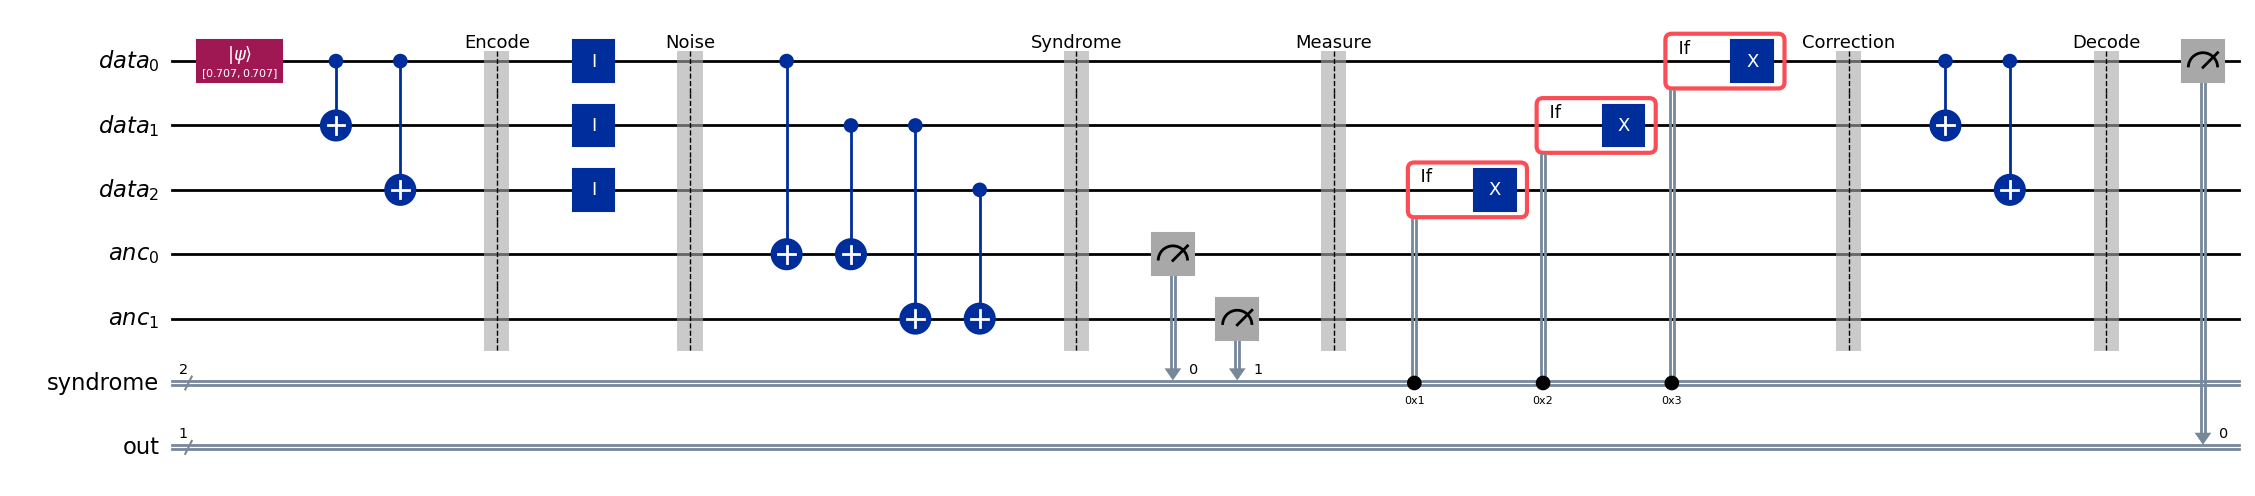

In [ ]:
def prepare_state(qc, qubit, alpha, beta):
    """
    Prepare state: alpha|0> + beta|1>
    """
    norm = np.sqrt(abs(alpha)**2 + abs(beta)**2)
    alpha, beta = alpha/norm, beta/norm

    qc.initialize([alpha, beta], qubit)

def no_qec(alpha, beta):
    qc = QuantumCircuit(1,1)
    prepare_state(qc, 0, alpha, beta)
    qc.id(0)   # noisy channel
    qc.measure(0,0)
    return qc

def bitflip_qec(alpha, beta):
    # Quantum registers
    data = QuantumRegister(3, 'data')     # data qubits
    anc  = QuantumRegister(2, 'anc')      # syndrome qubits
    # Classical registers
    synd = ClassicalRegister(2, 'syndrome')
    out  = ClassicalRegister(1, 'out')

    qc = QuantumCircuit(data, anc, synd, out)

    # 1. Prepare state |ψ⟩ = alpha|0> + beta|1>
    prepare_state(qc, data[0], alpha, beta)

    # 2. Encoding
    qc.cx(data[0], data[1])
    qc.cx(data[0], data[2])
    qc.barrier(label="Encode")

    # 3. Noisy channel (acts here via noise model)
    qc.id(data)
    qc.barrier(label="Noise")

    # 4. Syndrome Extraction
    # Z0Z1 ---> anc[0]
    qc.cx(data[0], anc[0])
    qc.cx(data[1], anc[0])
    # Z1Z2 ----> anc[1]
    qc.cx(data[1], anc[1])
    qc.cx(data[2], anc[1])
    qc.barrier(label="Syndrome")
    # Measure syndrome
    qc.measure(anc, synd)
    qc.barrier(label="Measure")

    # 5. Classical Correction using if_else
    # Case 01 → error on qubit 2
    with qc.if_test((synd, 1)):
        qc.x(data[2])
    # Case 10 → error on qubit 1
    with qc.if_test((synd, 2)):
        qc.x(data[1])
    # Case 11 → error on qubit 0
    with qc.if_test((synd, 3)):
        qc.x(data[0])
    qc.barrier(label="Correction")

    # 6. Decode
    qc.cx(data[0], data[1])
    qc.cx(data[0], data[2])

    qc.barrier(label="Decode")

    # 7. Final Measurement
    qc.measure(data[0], out[0])

    return qc

def bit_flip_noise(p=0.1):
    noise = NoiseModel()
    error = pauli_error([('X', p), ('I', 1-p)])
    noise.add_all_qubit_quantum_error(error, ['id','x'])
    return noise


# Defining Parameters
# alpha = 0
# beta  = 1
alpha = 1/np.sqrt(2)
beta  = 1/np.sqrt(2)

qc_no = no_qec(alpha, beta)
qc_qec = bitflip_qec(alpha, beta)

sim = AerSimulator(noise_model=bit_flip_noise(p=0.3), shots=1024)

res_no = sim.run(transpile(qc_no, sim)).result().get_counts()
res_qec = sim.run(transpile(qc_qec, sim)).result().get_counts()

print("No QEC:", res_no)
print("With QEC:", res_qec)

qc_qec.draw("mpl", fold=-1)

<div style="
font-family:'Times New Roman', serif;
font-size:16px;
line-height:1.6;
background:linear-gradient(135deg,#eef2ff,#e0f7fa);
padding:14px;
border-radius:10px;
border:1px solid #c5cae9;
box-shadow:0 2px 8px rgba(0,0,0,0.06);">

<h3 style="margin:0; color:#1a237e; font-weight:600;">
📊 QECC Performance Test
</h3>

<p style="margin:8px 0 6px 0; color:#37474f;">
We transmit a bitstring through a noisy quantum channel and compare:
</p>

<ul style="margin:6px 0; padding-left:18px; color:#263238;">
<li><b>Direct transmission</b> (no correction)</li>
<li><b>With 3-qubit bit-flip QEC</b></li>
</ul>

<p style="margin:8px 0; color:#37474f;">
Performance is measured using:
</p>

<p style="text-align:center; margin:6px 0; font-size:17px; color:#0d47a1;">
$\text{BER} = \frac{\text{Number of errors}}{\text{Total bits}}$
</p>

<p style="margin:8px 0 0 0; color:#37474f;">
Lower BER ⇒ better error correction performance.
</p>

</div>

In [ ]:
import random

# Generate a random bitstring (our "information")
def generate_bitstring(n=20):
    """Generate a random binary string of length n."""
    return ''.join(random.choice(['0','1']) for _ in range(n))

# Send a single bit WITHOUT error correction
def send_bit_no_qec(bit, noise_model, shots=1):
    qc = QuantumCircuit(1,1)
    if bit == '1':
        qc.x(0)
    qc.id(0)
    qc.measure(0,0)

    sim = AerSimulator(noise_model=noise_model, shots=shots)
    result = sim.run(transpile(qc, sim)).result()
    counts = result.get_counts()
    return max(counts, key=counts.get)

# Send a single bit WITH QEC
def send_bit_qec(bit, noise_model, shots=1):
    alpha = 1 if bit == '0' else 0
    beta  = 1 if bit == '1' else 0
    qc = bitflip_qec(alpha, beta)

    sim = AerSimulator(noise_model=noise_model)
    result = sim.run(transpile(qc, sim), shots=shots).result()
    counts = result.get_counts()
    measured = max(counts, key=counts.get)
    return measured[0]


# Transmit full bitstring
def transmit(bitstring, noise_model, use_qec=False):
    received = ""
    for bit in bitstring:
        if use_qec:
            received += send_bit_qec(bit, noise_model)
        else:
            received += send_bit_no_qec(bit, noise_model)

    return received

# Compute Bit Error Rate (BER)
def bit_error_rate(original, received):
    errors = sum(o != r for o, r in zip(original, received))
    return errors / len(original)

In [ ]:
bitstring = generate_bitstring(30)
noise = bit_flip_noise(p=0.3)

received_no = transmit(bitstring, noise, use_qec=False)
received_qec = transmit(bitstring, noise, use_qec=True)

print("Original :", bitstring)
print("No QEC   :", received_no)
print("With QEC :", received_qec)

print("\nError rate (No QEC):", bit_error_rate(bitstring, received_no))
print("Error rate (QEC):", bit_error_rate(bitstring, received_qec))

Original : 010011010011000100110011101110
No QEC   : 000000010011000100110011101110
With QEC : 010011010011000100110011101110

Error rate (No QEC): 0.1
Error rate (QEC): 0.0


<div style="font-family:'Times New Roman', serif; font-size:16px; line-height:1.7;">

<h3 style="color:green; font-weight:600;">
2.2 Phase-Flip Error Correction (3-Qubit Code)
</h3>

<p>
Consider a qubit transmitted through a noisy channel: $|\psi\rangle = \alpha|0\rangle + \beta|1\rangle$
</p>

<p>
Unlike bit-flip errors, phase-flip ($Z$) errors do not change the computational basis states directly, but instead flip the relative phase:
</p>

<p style="text-align:center;">
$Z|\psi\rangle = \alpha|0\rangle - \beta|1\rangle$
</p>

<p>
To correct phase errors, we use a clever basis transformation. First, we convert the qubit into the $X$-basis using Hadamard gates:
</p>

<p style="text-align:center;">
$|0\rangle \rightarrow |+\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}}, \quad
|1\rangle \rightarrow |-\rangle = \frac{|0\rangle - |1\rangle}{\sqrt{2}}$
</p>

<p>
In this basis, a phase-flip behaves like a bit-flip. Therefore, we can reuse the 3-qubit repetition strategy.
</p>

<p>
The encoded state becomes:
</p>

<p style="text-align:center;">
$|\psi_1\rangle = \alpha|+++\rangle + \beta|---\rangle$
</p>

<p>
This encoding is implemented using Hadamard gates followed by CNOT operations.
</p>

<p>
During transmission, a phase-flip error may occur on any qubit:
</p>

<ul>
<li>$\alpha|+++\rangle + \beta|---\rangle$ (no error)</li>
<li>Error on qubit 1</li>
<li>Error on qubit 2</li>
<li>Error on qubit 3</li>
</ul>

<div style="text-align:center; margin:15px 0;">
<img src="https://raw.githubusercontent.com/qiskit-community/qiskit-community-tutorials/a6206e42a770a04cb1f650b3b1a20ea1625152e4/awards/teach_me_quantum_2018/intro2qc/figures/10/phase_error2.jpeg"
width="80%" style="border-radius:8px; box-shadow:0 2px 8px rgba(0,0,0,0.08);">

<p style="text-align:center;font-size:14px; color:#555; margin-top:6px;">
<b>Figure:</b> Quantum circuit for 3-qubit phase-flip error correction
</p>
</div>

<p>
To detect errors, we again perform parity checks using ancilla qubits. However, since we are working in the $X$-basis, the effective stabilizers correspond to:
</p>

<p style="text-align:center;">
$X_0X_1, \quad X_1X_2$
</p>

<p>
These checks identify the error location through syndrome measurement:
</p>

<ul>
<li>$00$ → No error</li>
<li>$01$ → Error on qubit 3</li>
<li>$10$ → Error on qubit 2</li>
<li>$11$ → Error on qubit 1</li>
</ul>

<p>
Correction is applied by performing an $X$ operation in the transformed basis, which corresponds to a $Z$ correction in the original basis.
</p>

<p>
After correction, the encoded state is restored:
</p>

<p style="text-align:center;">
$|\psi_5\rangle = \alpha|+++\rangle + \beta|---\rangle$
</p>

<p>
Finally, applying Hadamard gates again (inverse transformation) returns the state to the computational basis:
</p>

<p style="text-align:center;">
$|\psi\rangle = \alpha|0\rangle + \beta|1\rangle$
</p>

<p>
Thus, phase-flip errors are successfully corrected by transforming them into bit-flip errors in a different basis.
</p>

</div>


{'1 01': 82, '1 11': 68, '0 11': 85, '1 00': 280, '1 10': 84, '0 01': 86, '0 10': 99, '0 00': 240}


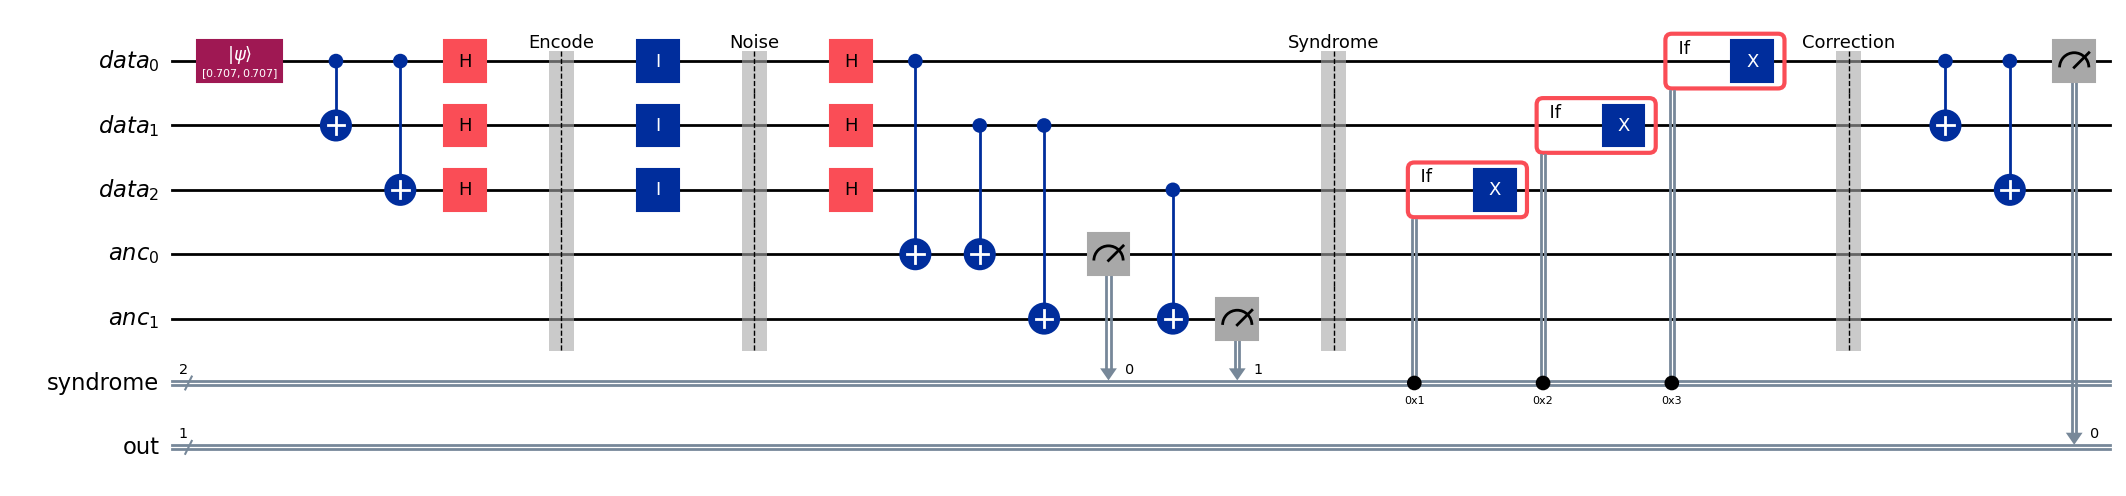

In [ ]:
# Phase Flip QEC
def phaseflip_qec(alpha, beta):
    # Quantum registers
    data = QuantumRegister(3, 'data')
    anc  = QuantumRegister(2, 'anc')
    # Classical registers
    synd = ClassicalRegister(2, 'syndrome')
    out  = ClassicalRegister(1, 'out')

    qc = QuantumCircuit(data, anc, synd, out)

    # 1. Initial state
    prepare_state(qc, data[0], alpha, beta)

    # 2. Encode (CNOTs)
    qc.cx(data[0], data[1])
    qc.cx(data[0], data[2])

    # 3. Convert to X-basis (H)
    qc.h(data)
    qc.barrier(label="Encode")

    # 4. Phase noise channel
    qc.id(data)
    qc.barrier(label="Noise")

    # 5. Convert back (H)
    qc.h(data)

    # 6. Syndrome extraction
    qc.cx(data[0], anc[0])
    qc.cx(data[1], anc[0])
    qc.cx(data[1], anc[1])
    qc.cx(data[2], anc[1])
    qc.measure(anc, synd)
    qc.barrier(label="Syndrome")

    # 7. Correction (conditional)
    with qc.if_test((synd, 1)):
        qc.x(data[2])
    with qc.if_test((synd, 2)):
        qc.x(data[1])
    with qc.if_test((synd, 3)):
        qc.x(data[0])
    qc.barrier(label="Correction")

    # 8. Decode
    qc.cx(data[0], data[1])
    qc.cx(data[0], data[2])

    # 9. Measure logical qubit
    qc.measure(data[0], out[0])

    return qc

def phase_flip_noise(p=0.1):
    noise = NoiseModel()
    error = pauli_error([('Z', p), ('I', 1-p)])
    noise.add_all_qubit_quantum_error(error, ['x','id'])
    return noise

alpha = 0
beta  = 1
alpha = 1/np.sqrt(2)
beta  = 1/np.sqrt(2)

qc = phaseflip_qec(alpha, beta)

sim = AerSimulator(noise_model=phase_flip_noise(p=0.2), shots=1024)

counts = sim.run(qc).result().get_counts()

print(counts)
qc.draw("mpl", fold=-1)

In [ ]:
import random

# Generate a random bitstring (our "information")
def generate_bitstring(n=20):
    """Generate a random binary string of length n."""
    return ''.join(random.choice(['0','1']) for _ in range(n))

# Send a single bit WITHOUT error correction
def send_bit_no_qec(bit, noise_model, shots=1):
    qc = QuantumCircuit(1,1)
    if bit == '1':
        qc.x(0)
    qc.h(0)
    qc.id(0)
    qc.h(0)
    qc.measure(0,0)

    sim = AerSimulator(noise_model=noise_model, shots=shots)
    result = sim.run(transpile(qc, sim)).result()
    counts = result.get_counts()
    return max(counts, key=counts.get)

# Send a single bit WITH QEC
def send_bit_qec(bit, noise_model, shots=1):
    alpha = 1 if bit == '0' else 0
    beta  = 1 if bit == '1' else 0
    qc = phaseflip_qec(alpha, beta)

    sim = AerSimulator(noise_model=noise_model, shots=shots)
    result = sim.run(transpile(qc, sim)).result()
    counts = result.get_counts()
    measured = max(counts, key=counts.get)
    return measured[0]


# Transmit full bitstring
def transmit_phase(bitstring, noise_model, use_qec=False):
    received = ""
    for bit in bitstring:
        if use_qec:
            received += send_bit_qec(bit, noise_model)
        else:
            received += send_bit_no_qec(bit, noise_model)

    return received

# Compute Bit Error Rate (BER)
def bit_error_rate(original, received):
    errors = sum(o != r for o, r in zip(original, received))
    return errors / len(original)

In [ ]:
bitstring = generate_bitstring(30)
noise = phase_flip_noise(p=0.1)

received_no = transmit_phase(bitstring, noise, use_qec=False)
received_qec = transmit_phase(bitstring, noise, use_qec=True)

print("Original :", bitstring)
print("No QEC   :", received_no)
print("With QEC :", received_qec)

print("\nError rate (No QEC):", bit_error_rate(bitstring, received_no))
print("Error rate (QEC):", bit_error_rate(bitstring, received_qec))

Original : 111000000000011001000111100110
No QEC   : 111000000000011001000111100110
With QEC : 111000000000011001000111100110

Error rate (No QEC): 0.0
Error rate (QEC): 0.0


<div style="font-family:'Times New Roman', serif; font-size:16px; line-height:1.7;">

<h3 style="color:green; font-weight:600;">
2.3 Shor Code (9-Qubit Error Correction)
</h3>

<p>
The 3-qubit bit-flip and phase-flip codes can correct only one type of error at a time. However, realistic quantum noise can introduce both bit-flip ($X$) and phase-flip ($Z$) errors. The Shor code, proposed by Peter Shor, is the first quantum error correction code capable of correcting <b>arbitrary single-qubit errors</b>.
</p>

<p>
It achieves this by combining both bit-flip and phase-flip protection using a 9-qubit encoding scheme.
</p>
</div>


In [ ]:
def shor_noise(p=0.1):
    noise = NoiseModel()

    # General Pauli error (X, Z, Y)
    error = pauli_error([
        ('X', p/3),
        ('Z', p/3),
        ('Y', p/3),
        ('I', 1-p)
    ])

    # Apply to ALL relevant gates
    noise.add_all_qubit_quantum_error(error, ['x','h','id','z'])

    return noise

def no_qec(alpha, beta):
    qc = QuantumCircuit(1,1)
    prepare_state(qc, 0, alpha, beta)

    # Minimal gates so noise acts
    qc.h(0)
    qc.h(0)

    qc.measure(0,0)
    return qc

def shor_qec(alpha, beta):

    data = QuantumRegister(9, 'data')
    anc  = QuantumRegister(8, 'anc')
    synd = ClassicalRegister(8, 'syndrome')
    out  = ClassicalRegister(1, 'out')

    qc = QuantumCircuit(data, anc, synd, out)

    # 1. Prepare state
    prepare_state(qc, data[0], alpha, beta)

    # 2. Phase encoding
    qc.cx(data[0], data[3])
    qc.cx(data[0], data[6])

    qc.h(data[0])
    qc.h(data[3])
    qc.h(data[6])

    # 3. Bit-flip encoding
    for i in [0,3,6]:
        qc.cx(data[i], data[i+1])
        qc.cx(data[i], data[i+2])

    qc.barrier(label="Encode")

    # 4. Bit-flip syndrome
    # Block 1
    qc.cx(data[0], anc[0])
    qc.cx(data[1], anc[0])
    qc.cx(data[1], anc[1])
    qc.cx(data[2], anc[1])

    # Block 2
    qc.cx(data[3], anc[2])
    qc.cx(data[4], anc[2])
    qc.cx(data[4], anc[3])
    qc.cx(data[5], anc[3])

    # Block 3
    qc.cx(data[6], anc[4])
    qc.cx(data[7], anc[4])
    qc.cx(data[7], anc[5])
    qc.cx(data[8], anc[5])

    qc.barrier(label="Bit Syndrome")

    # 5. Phase-flip syndrome
    qc.h(data)

    qc.cx(data[0], anc[6])
    qc.cx(data[3], anc[6])
    qc.cx(data[3], anc[7])
    qc.cx(data[6], anc[7])

    qc.h(data)

    qc.barrier(label="Phase Syndrome")

    # 6. Measure syndrome
    qc.measure(anc, synd)

    qc.barrier(label="Measure")

    # 7. Simplified correction
    with qc.if_test((synd, 1)):
        qc.x(data[2])
    with qc.if_test((synd, 2)):
        qc.x(data[1])
    with qc.if_test((synd, 3)):
        qc.x(data[0])

    qc.barrier(label="Correction")

    # 8. Decode
    for i in [0,3,6]:
        qc.cx(data[i], data[i+1])
        qc.cx(data[i], data[i+2])

    qc.h(data[0])
    qc.h(data[3])
    qc.h(data[6])

    qc.cx(data[0], data[3])
    qc.cx(data[0], data[6])

    qc.barrier(label="Decode")

    # 9. Final measurement
    qc.measure(data[0], out[0])

    return qc

No QEC: {'0': 543, '1': 481}
Shor QEC: {'1 01000000': 139, '1 00000000': 130, '1 11000000': 125, '0 11000000': 121, '0 01000000': 125, '0 10000000': 137, '1 10000000': 122, '0 00000000': 125}


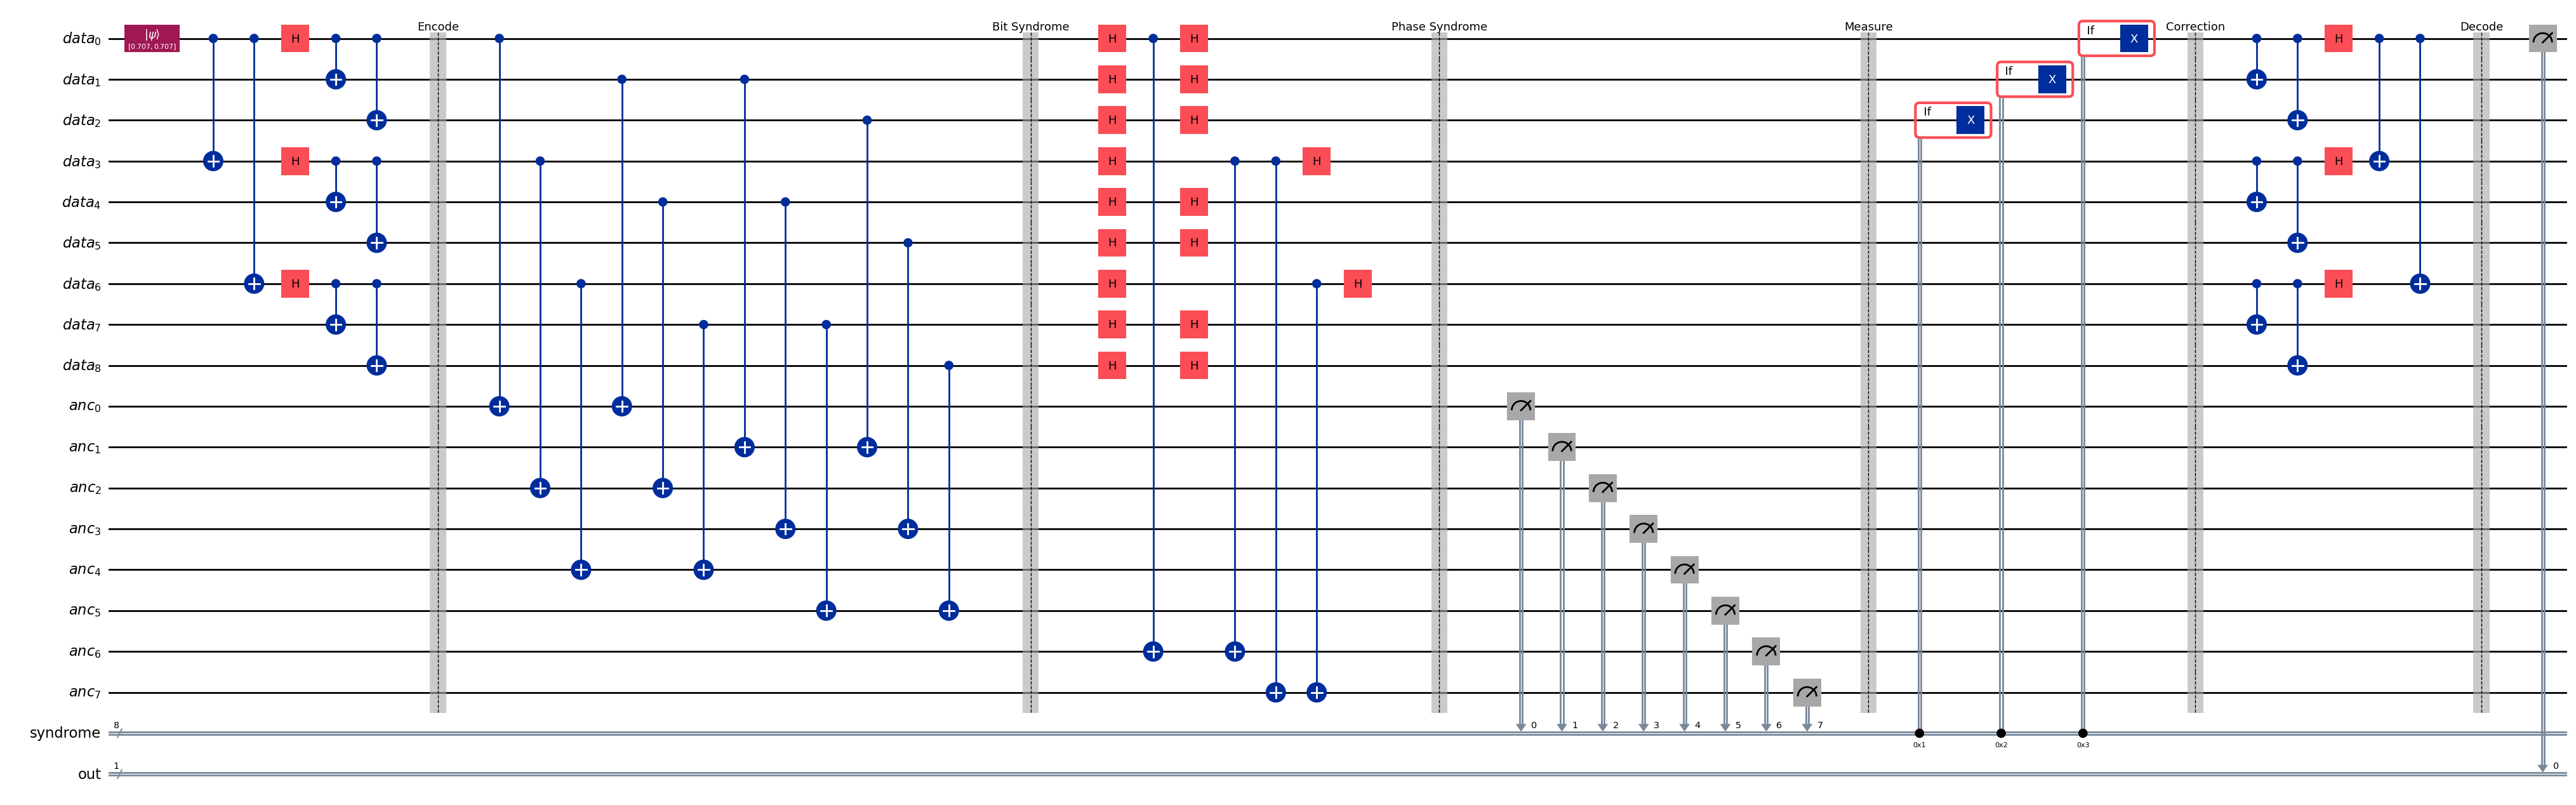

In [ ]:
alpha = 1/np.sqrt(2)
beta  = 1/np.sqrt(2)

qc_no  = no_qec(alpha, beta)
qc_qec = shor_qec(alpha, beta)

noise = shor_noise(p=0.2)

sim = AerSimulator(noise_model=noise, shots=1024)

res_no  = sim.run(transpile(qc_no, sim)).result().get_counts()
res_qec = sim.run(transpile(qc_qec, sim)).result().get_counts()

print("No QEC:", res_no)
print("Shor QEC:", res_qec)

qc_qec.draw("mpl", fold=-1)

In [ ]:
def send_bit_no_qec(bit, noise_model, shots=1):
    qc = QuantumCircuit(1,1)

    if bit == '1':
        qc.x(0)

    # Add real gates so noise acts
    qc.h(0)
    qc.h(0)

    qc.measure(0,0)

    sim = AerSimulator(noise_model=noise_model, shots=shots)
    result = sim.run(transpile(qc, sim)).result()
    counts = result.get_counts()

    return max(counts, key=counts.get)

def send_bit_shor(bit, noise_model, shots=1):
    alpha = 1 if bit == '0' else 0
    beta  = 1 if bit == '1' else 0

    qc = shor_qec(alpha, beta)

    sim = AerSimulator(noise_model=noise_model, shots=shots)
    result = sim.run(transpile(qc, sim)).result()
    counts = result.get_counts()

    measured = max(counts, key=counts.get)

    return measured[0]

def transmit(bitstring, noise_model, mode="none"):
    received = ""

    for bit in bitstring:
        if mode == "none":
            received += send_bit_no_qec(bit, noise_model)
        elif mode == "bitflip":
            received += send_bit_qec(bit, noise_model)
        elif mode == "shor":
            received += send_bit_shor(bit, noise_model)

    return received

bitstring = generate_bitstring(50)

noise = shor_noise(p=0.01)

received_no_qec = transmit(bitstring, noise, mode="none")
received_shor   = transmit(bitstring, noise, mode="shor")

ber_no_qec = bit_error_rate(bitstring, received_no_qec)
ber_shor   = bit_error_rate(bitstring, received_shor)

print("Original: ", bitstring)
print("No QEC:   ", received_no_qec)
print("Shor QEC: ", received_shor)

print("\nBER (No QEC):", ber_no_qec)
print("BER (Shor):  ", ber_shor)

Original:  10000101001011011111110100110000110000011111000100
No QEC:    10000101001011011111110100110000110000011111000100
Shor QEC:  10000101001011011111110100010000110000011101100100

BER (No QEC): 0.0
BER (Shor):   0.06
